# roll组件复现原子子组合价值_gmat3对照

这份 notebook 的目标很明确：

- 使用 `strategies/components/roll/` 里的通用 roll 组件
- 复现 GMAT3 的原子子组合价值
- 与 `ddb` 项目已经产出的结果做直接对照

当前先只比较 `AU / CU / M`，因为这三类都属于当前 roll 组件已经能较严肃表达的 **境内商品 single-asset roll** 规则族。


## 为什么先选 AU / CU / M

因为这一步的硬约束是：**比较前先确保两边 roll rule 参数配置一致**。

当前 `components/roll` 层里，已经有最明确的 GMAT3 适配能力的是 `gmat3_domestic_commodity` 这类规则；
所以先用 `AU / CU / M` 做对照，能避免把股指、海外窗口规则、或者 `BLACK` 这种 bundle 逻辑混在一起。


In [1]:
%matplotlib inline

from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path('/home/ubuntu/dengl/my_projects/cta_lab')
PROJECT_ROOT = ROOT.parent
DDB_ROOT = PROJECT_ROOT / 'ddb'

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import strategies.components.roll as roll_pkg
import strategies.components.roll.gmat3_adapter as roll_gmat3_adapter_mod

importlib.reload(roll_gmat3_adapter_mod)
importlib.reload(roll_pkg)

from strategies.components.roll import (
    ExecutionRuleConfig,
    GMAT3SingleAssetRollStrategy,
    LifecycleRuleConfig,
    MarketStateRuleConfig,
    RollStrategyProfile,
    SelectorRuleConfig,
)
from strategies.implementations.gmat3 import GMAT3DataAccess
from strategies.implementations.gmat3.universe import ROLL_PARAMS, SUB_PORTFOLIOS

plt.rcParams['figure.dpi'] = 120
ROOT, DDB_ROOT


(PosixPath('/home/ubuntu/dengl/my_projects/cta_lab'),
 PosixPath('/home/ubuntu/dengl/my_projects/ddb'))

## 1. 读取 ddb 侧原子子组合价值文件

`GMAT3_SUB_PORT_VALUE.csv` 是 ddb 侧已经产出的原子子组合价值序列。
这里对应关系先只取：
- `AU -> CISAUER.WI`
- `CU -> CISCUER.WI`
- `M  -> CISMER.WI`


In [2]:
legacy_path = DDB_ROOT / 'data' / 'raw' / 'GMAT3_SUB_PORT_VALUE.csv'
legacy_df = pd.read_csv(legacy_path)
legacy_df['day'] = pd.to_datetime(legacy_df['day'])
legacy_df = legacy_df.set_index('day').sort_index()

legacy_col_map = {
    'AU': 'CISAUER.WI',
    'CU': 'CISCUER.WI',
    'M': 'CISMER.WI',
}
legacy_df[list(legacy_col_map.values())].head()


,CISAUER.WI,CISCUER.WI,CISMER.WI
day,,,
2005-01-04,NaN,1000.000000,1000.000000
2005-01-05,NaN,969.854470,995.813953
2005-01-06,NaN,983.367983,1003.720930
2005-01-07,NaN,984.753985,1013.488372
2005-01-10,NaN,979.902980,1014.418605


## 2. 用通用 roll 组件复现同一批原子子组合

这里直接使用 `GMAT3SingleAssetRollStrategy`，因为它已经把：
- `GMAT3DataAccess`
- generic contract universe
- `ROLL_PARAMS` 里的 `roll_days`
- `gmat3_domestic_commodity` 市场状态规则
串成了一条较接近 GMAT3 境内商品原子子组合的 single-asset 路径。


## 2.1 显式固定 roll rule 参数

为了保证这次比较有意义，这里不依赖 `GMAT3SingleAssetRollStrategy` 的隐式默认值，
而是直接从 `ROLL_PARAMS` 中读取 `roll_days`，并在 notebook 中显式构造：
- `LifecycleRuleConfig`
- `MarketStateRuleConfig`
- `ExecutionRuleConfig`
- `SelectorRuleConfig`

这样可以直接看到：`cta_lab` 这条对照路径使用的参数口径，是否与 `ddb` 侧一致。


In [3]:
varieties = ['AU', 'CU', 'M']
rule_param_rows = []
explicit_profiles = {}

for variety in varieties:
    cfg = SUB_PORTFOLIOS[variety]
    roll_cfg = ROLL_PARAMS[variety]
    roll_days = int(roll_cfg['roll_days'])

    explicit_profiles[variety] = RollStrategyProfile(
        name=f'gmat3_{variety.lower()}_explicit_compare',
        asset_key=variety,
        asset_mode='single',
        currency=str(cfg.get('currency', 'CNY')),
        rule_profile='gmat3_domestic_commodity',
        roll_days=roll_days,
        lifecycle_date_field='last_holding_date',
        market_state_field='open_interest',
        lifecycle_rule_config=LifecycleRuleConfig(
            kind='fixed_days_before_expiry',
            params={'roll_days': roll_days, 'date_field': 'last_holding_date'},
        ),
        market_state_rule_config=MarketStateRuleConfig(
            kind='gmat3_domestic_commodity',
            params={},
        ),
        execution_rule_config=ExecutionRuleConfig(
            kind='linear',
            params={'roll_days': roll_days},
        ),
        selector_rule_config=SelectorRuleConfig(
            kind='prefer_selected',
            params={},
        ),
        metadata={
            'source': 'gmat3_compare_notebook',
            'contract_type': cfg.get('contract_type'),
            'roll_rule_expected': roll_cfg.get('last_holding_rule'),
        },
    )

    rule_param_rows.append({
        'variety': variety,
        'contract_type': cfg.get('contract_type'),
        'ddb_roll_days': roll_days,
        'ddb_last_holding_rule': roll_cfg.get('last_holding_rule'),
        'cta_lifecycle_kind': explicit_profiles[variety].lifecycle_rule_config.kind,
        'cta_market_state_kind': explicit_profiles[variety].market_state_rule_config.kind,
        'cta_execution_kind': explicit_profiles[variety].execution_rule_config.kind,
        'cta_selector_kind': explicit_profiles[variety].selector_rule_config.kind,
    })

rule_param_df = pd.DataFrame(rule_param_rows).set_index('variety')
rule_param_df


,contract_type,ddb_roll_days,ddb_last_holding_rule,cta_lifecycle_kind,cta_market_state_kind,cta_execution_kind,cta_selector_kind
variety,,,,,,,
AU,domestic_commodity,3,prev_2_month_last,fixed_days_before_expiry,gmat3_domestic_commodity,linear,prefer_selected
CU,domestic_commodity,3,prev_2_month_last,fixed_days_before_expiry,gmat3_domestic_commodity,linear,prefer_selected
M,domestic_commodity,3,prev_1_month_14th,fixed_days_before_expiry,gmat3_domestic_commodity,linear,prefer_selected


In [4]:
access = GMAT3DataAccess()
cta_lab_values = {}

for variety in varieties:
    strategy = GMAT3SingleAssetRollStrategy(
        access,
        variety,
        profile=explicit_profiles[variety],
    )
    result = strategy.run_from_access(end='2024-12-31')
    # ddb 文件是 1000 base，这里做同口径缩放
    cta_lab_values[variety] = result.value_series * 1000.0

cta_lab_df = pd.DataFrame(cta_lab_values).sort_index()
cta_lab_df.head()


,AU,CU,M
trade_date,,,
2005-01-04,NaN,1000.0,1000.0
2005-01-05,NaN,969.85447,995.813953
2005-01-06,NaN,983.367983,1003.72093
2005-01-07,NaN,984.753985,1013.488372
2005-01-10,NaN,979.90298,1014.418605


## 3. 对齐日期并做指标比较

这里看 4 个最直接的比较量：
- overlap 样本长度
- 日收益相关性
- 末值比值
- 最大绝对净值差


In [5]:
comparison = {}
for variety in varieties:
    legacy = legacy_df[legacy_col_map[variety]].dropna().rename('legacy')
    ours = cta_lab_df[variety].dropna().rename('cta_lab')
    merged = pd.concat([legacy, ours], axis=1).dropna()

    legacy_ret = merged['legacy'].pct_change()
    ours_ret = merged['cta_lab'].pct_change()
    corr = legacy_ret.corr(ours_ret)

    comparison[variety] = {
        'n_obs': len(merged),
        'ret_corr': corr,
        'legacy_last': merged['legacy'].iloc[-1],
        'cta_lab_last': merged['cta_lab'].iloc[-1],
        'last_ratio': merged['cta_lab'].iloc[-1] / merged['legacy'].iloc[-1],
        'max_abs_diff': (merged['cta_lab'] - merged['legacy']).abs().max(),
    }

comparison_df = pd.DataFrame(comparison).T
comparison_df


,n_obs,ret_corr,legacy_last,cta_lab_last,last_ratio,max_abs_diff
AU,4127.0,0.988527,2239.069436,2455.678430,1.096741,247.433793
CU,4860.0,0.989552,4636.195809,7313.597350,1.577500,4499.177731
M,4860.0,0.978489,4155.560016,6963.551353,1.675719,3770.794169


## 4. 画图看净值路径差异


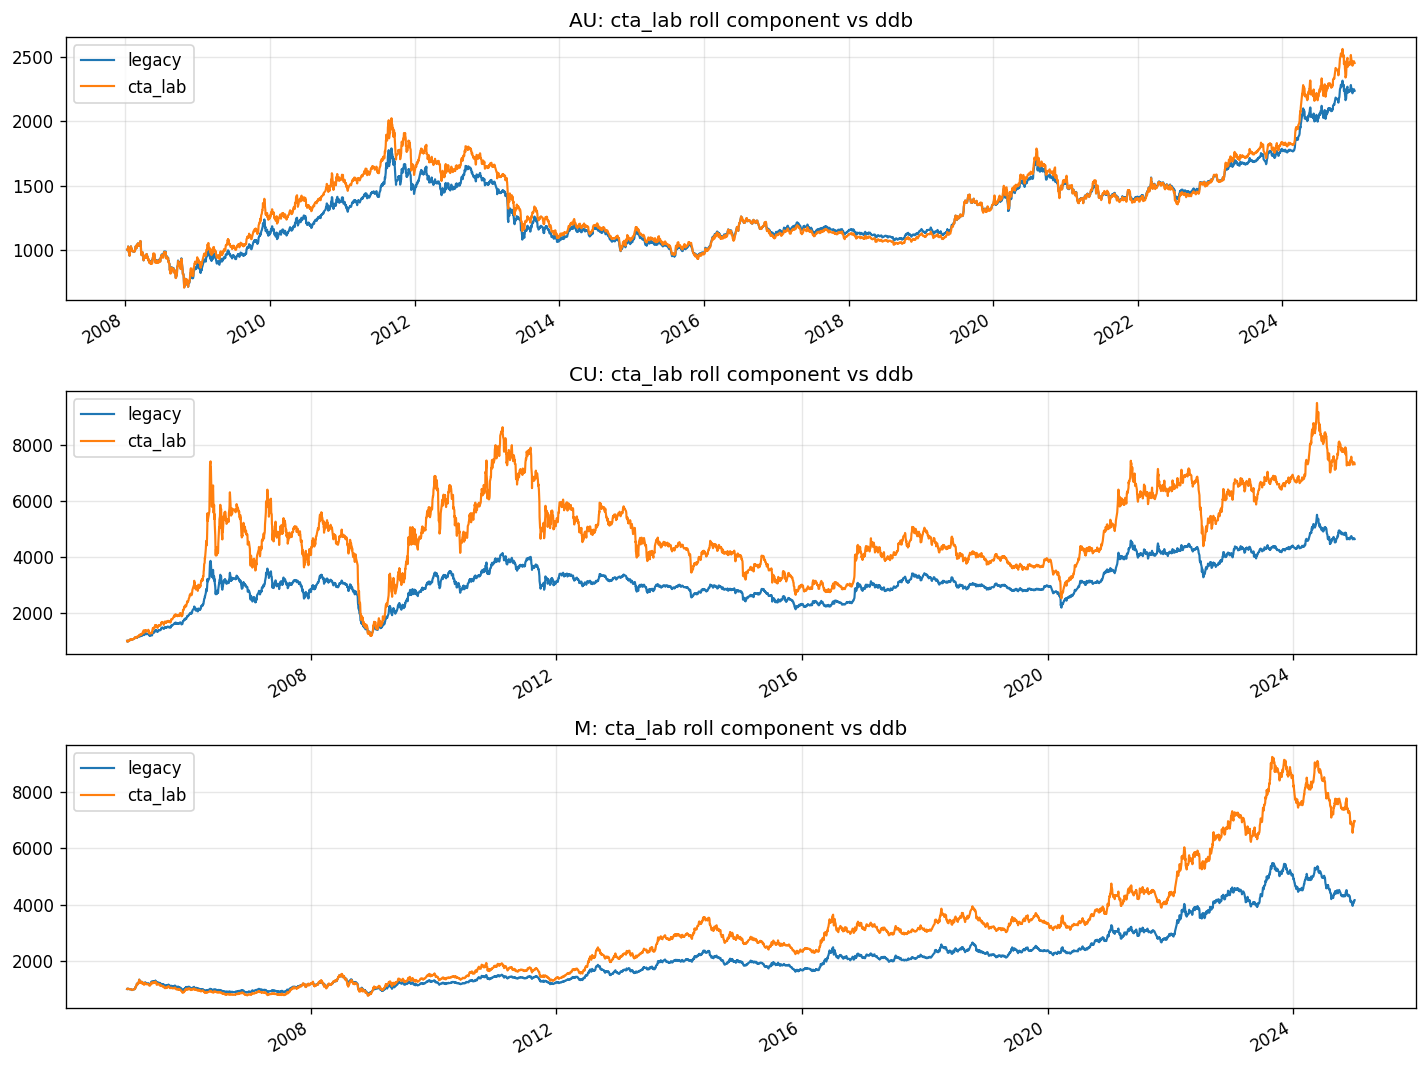

In [6]:
fig, axes = plt.subplots(len(varieties), 1, figsize=(12, 9), sharex=False)
if len(varieties) == 1:
    axes = [axes]

for ax, variety in zip(axes, varieties):
    legacy = legacy_df[legacy_col_map[variety]].dropna().rename('legacy')
    ours = cta_lab_df[variety].dropna().rename('cta_lab')
    merged = pd.concat([legacy, ours], axis=1).dropna()
    merged.plot(ax=ax, lw=1.3)
    ax.set_title(f'{variety}: cta_lab roll component vs ddb')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. 先怎么看结果

这一步不是要求一上来完全重合，而是优先判断：

1. 路径形态是否已经接近
2. 日收益相关性是否较高
3. 偏差更像是：
   - roll rule 参数没完全对齐
   - generic contract universe 口径差异
   - execution / smoothing 细节差异

如果这三条原子子组合已经比较接近，就说明：
**当前通用 roll 组件已经具备复现 ddb 原子子组合价值的现实基础。**
